In [1]:
# ============================================================
# 0. 기본 세팅
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
import time

import torch
import torch.nn as nn
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc, confusion_matrix
)

warnings.filterwarnings("ignore")

# 재현성
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 디바이스 선택
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

# 데이터 경로 (Colab 기준 - 상황에 맞게 수정)
DATA_PATH = "/content/amazon_train.csv"


Device: cuda


In [2]:
# ============================================================
# 1. 데이터 로딩 & 간단한 분석
# ============================================================
df = pd.read_csv(DATA_PATH)
print(df.head())

# rating 칼럼이 없으면 전부 1로 만든다 (문제에서 rating 무시 가능)
if "rating" not in df.columns:
    df["rating"] = 1.0

# 기본 통계
print("\n[기본 통계]")
print("행 개수 (interaction 수):", len(df))
print("유저 수:", df["user"].nunique())
print("아이템 수:", df["item"].nunique())
print("rating 요약:\n", df["rating"].describe())

n_users_raw = df["user"].nunique()
n_items_raw = df["item"].nunique()
num_interactions = len(df)

# sparse 정도
sparsity = 1.0 - num_interactions / (n_users_raw * n_items_raw)
print(f"\n대략 sparsity: {sparsity * 100:.2f}% (0%면 촘촘, 100%면 매우 희소)")

# 유저별 구매 개수 분포
user_counts = df.groupby("user").size()
print("\n유저당 평균 구매 수:", user_counts.mean())
print("유저당 구매 수 분포(앞 부분):")
print(user_counts.describe())


             user        item  rating
0  A395BORC6FGVXV  B000UA0QIQ       2
1  A1UQRSCLF8GW1T  B006K2ZZ7K       5
2   ADT0SRK1MGOEU  B006K2ZZ7K       4
3  A1SP2KVKFXXRU1  B006K2ZZ7K       5
4  A3JRGQVEQN31IQ  B006K2ZZ7K       5

[기본 통계]
행 개수 (interaction 수): 568263
유저 수: 256009
아이템 수: 74233
rating 요약:
 count    568263.000000
mean          4.183185
std           1.310423
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64

대략 sparsity: 100.00% (0%면 촘촘, 100%면 매우 희소)

유저당 평균 구매 수: 2.2196993074462226
유저당 구매 수 분포(앞 부분):
count    256009.000000
mean          2.219699
std           4.440991
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         447.000000
dtype: float64


In [3]:
# ============================================================
# 2. ID → index 매핑 & user별 추천 개수 K 계산
# ============================================================

# user, item을 0 ~ N-1 index로 변환
user2idx = {u: i for i, u in enumerate(sorted(df["user"].unique()))}
item2idx = {it: i for i, it in enumerate(sorted(df["item"].unique()))}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

df["user_idx"] = df["user"].map(user2idx)
df["item_idx"] = df["item"].map(item2idx)

n_users = len(user2idx)
n_items = len(item2idx)

print("Index 변환 후 - users:", n_users, "items:", n_items)

# 유저별 interaction 수
user_interaction_count = df.groupby("user_idx").size().to_dict()

MAX_K = 50  # 과한 추천 방지 upper bound

def get_k_for_user(cnt: int) -> int:
    """
    cnt: 해당 유저가 train에서 구매한 아이템 수.
    - 10개 이하: 항상 2개 추천 (시험 제약)
    - 그 이상: 20%를 추천, 최소 2개, 최대 MAX_K
    """
    if cnt <= 10:
        return 2
    k = max(2, int(cnt * 0.2))
    return min(k, MAX_K)

user_k = {u: get_k_for_user(c) for u, c in user_interaction_count.items()}

print("\n샘플 user_k (앞 10명):")
for u in list(user_k.keys())[:10]:
    print(f"user_idx {u} (count={user_interaction_count[u]}): K={user_k[u]}")


Index 변환 후 - users: 256009 items: 74233

샘플 user_k (앞 10명):
user_idx 0 (count=1): K=2
user_idx 1 (count=1): K=2
user_idx 2 (count=1): K=2
user_idx 3 (count=1): K=2
user_idx 4 (count=1): K=2
user_idx 5 (count=2): K=2
user_idx 6 (count=1): K=2
user_idx 7 (count=3): K=2
user_idx 8 (count=1): K=2
user_idx 9 (count=2): K=2


In [4]:
# ============================================================
# 3. Train / Val / Test Split (user-wise)
# ============================================================

GOOD_RATING_THRESHOLD = 4.0  # 강병수 보고서 스타일 기준치 재사용

train_rows = []
val_rows = []
test_rows = []

for u_idx in range(n_users):
    u_df = df[df["user_idx"] == u_idx]

    # rating이 다 1인 경우(=정보 없음)라도 코드가 돌아가게 마련
    good = u_df[u_df["rating"] >= GOOD_RATING_THRESHOLD]
    bad  = u_df[u_df["rating"] < GOOD_RATING_THRESHOLD]

    # "나쁜" 구매는 전부 train으로 넣어 구조 학습에만 사용
    if len(bad) > 0:
        train_rows.append(bad)

    n_good = len(good)

    if n_good >= 3:
        good = good.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
        t_end = int(0.7 * n_good)
        v_end = t_end + int(0.15 * n_good)

        t_end = max(1, t_end)
        v_end = max(t_end + 1, v_end)

        train_rows.append(good.iloc[:t_end])
        val_rows.append(good.iloc[t_end:v_end])
        test_rows.append(good.iloc[v_end:])

    elif n_good == 2:
        good = good.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
        train_rows.append(good.iloc[:1])
        val_rows.append(good.iloc[1:])

    elif n_good == 1:
        train_rows.append(good)

train_df = pd.concat(train_rows, ignore_index=True)
val_df   = pd.concat(val_rows,   ignore_index=True) if val_rows else pd.DataFrame()
test_df  = pd.concat(test_rows,  ignore_index=True) if test_rows else pd.DataFrame()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# train에서 본 아이템은 나중에 추천에서 제외하기 위한 set
user_train_items = defaultdict(set)
for u, i in zip(train_df["user_idx"].values, train_df["item_idx"].values):
    user_train_items[int(u)].add(int(i))

print("예시 user_train_items[0]:", list(user_train_items[0])[:10])


Train: 451598, Val: 70050, Test: 46615
예시 user_train_items[0]: [69275]


In [5]:
# ============================================================
# 4. 그래프 구성 함수 (LightGCN용)
# ============================================================

def build_graphs_from_train(train_df, n_users, n_items):
    users   = train_df["user_idx"].values
    items   = train_df["item_idx"].values
    ratings = train_df["rating"].values

    # user 노드: [0, n_users)
    # item 노드: [n_users, n_users + n_items)
    u_nodes = users
    i_nodes = items + n_users

    edge_u2i = np.stack([u_nodes, i_nodes], axis=0)
    edge_i2u = np.stack([i_nodes, u_nodes], axis=0)
    edge_index = np.concatenate([edge_u2i, edge_i2u], axis=1)  # (2, 2E)

    edge_index = torch.LongTensor(edge_index).to(device)

    num_nodes = n_users + n_items

    deg = torch.zeros(num_nodes, device=device)
    ones = torch.ones(edge_index.size(1), device=device)
    deg = deg.scatter_add(0, edge_index[0], ones)  # out-degree

    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

    # A-버전: 단순 unweighted (symmetric norm)
    base_weight = deg_inv_sqrt[edge_index[0]] * deg_inv_sqrt[edge_index[1]]

    # B-버전: rating 가중치 (0.4 + 0.15 * rating) 사용
    rating_factor = 0.4 + 0.15 * ratings
    rating_factor_both = np.concatenate([rating_factor, rating_factor])
    rating_factor_both = torch.FloatTensor(rating_factor_both).to(device)

    weighted = base_weight * rating_factor_both

    return edge_index, base_weight, weighted

edge_index, edge_weight_conn, edge_weight_quality = build_graphs_from_train(
    train_df, n_users, n_items
)

print("그래프 구축 완료. edge 수:", edge_index.size(1))


그래프 구축 완료. edge 수: 903196


In [6]:
# ============================================================
# 5. GNN 모델 정의 (LightGCN + Rating MLP)
# ============================================================

class LightGCNEncoder(nn.Module):
    """
    유저/아이템 임베딩만 담당하는 LightGCN 인코더.
    """
    def __init__(self, n_users, n_items, emb_dim=32, n_layers=2):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.emb_dim = emb_dim
        self.n_layers = n_layers

        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)

        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

    def forward(self, edge_index, edge_weight):
        all_emb = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        embs = [all_emb]

        for _ in range(self.n_layers):
            row, col = edge_index  # (2, E)
            msg = all_emb[col] * edge_weight.unsqueeze(1)  # (E, d)
            agg = torch.zeros_like(all_emb)
            agg = agg.scatter_add_(0, row.unsqueeze(1).expand(-1, self.emb_dim), msg)
            all_emb = agg
            embs.append(all_emb)

        final_emb = torch.mean(torch.stack(embs, dim=0), dim=0)
        user_final = final_emb[:self.n_users]
        item_final = final_emb[self.n_users:]
        return user_final, item_final


class ConnectionModel(nn.Module):
    """
    단순 연결(좋은/나쁜)만 예측하는 모델.
    """
    def __init__(self, n_users, n_items, emb_dim=32, n_layers=2):
        super().__init__()
        self.encoder = LightGCNEncoder(n_users, n_items, emb_dim, n_layers)

    def forward(self, edge_index, edge_weight):
        return self.encoder(edge_index, edge_weight)

    def score(self, user_idx, item_idx, edge_index, edge_weight):
        u_emb, i_emb = self.encoder(edge_index, edge_weight)
        s = (u_emb[user_idx] * i_emb[item_idx]).sum(dim=-1)
        return s


class QualityModel(nn.Module):
    """
    LightGCN + MLP 헤드로 rating(0.5~5.0)을 예측하는 모델.
    """
    def __init__(self, n_users, n_items, emb_dim=32, n_layers=2):
        super().__init__()
        self.encoder = LightGCNEncoder(n_users, n_items, emb_dim, n_layers)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, edge_index, edge_weight):
        return self.encoder(edge_index, edge_weight)

    def predict_rating(self, user_idx, item_idx, edge_index, edge_weight):
        u_emb, i_emb = self.encoder(edge_index, edge_weight)
        inter = u_emb[user_idx] * i_emb[item_idx]
        logit = self.mlp(inter).squeeze(-1)
        rating = torch.sigmoid(logit) * 4.5 + 0.5  # [0.5, 5.0]
        return rating


In [7]:
# ============================================================
# 6. 학습 보조 함수들
# ============================================================

EMB_DIM   = 32
N_LAYERS  = 2
LR        = 5e-3
WEIGHT_DECAY = 1e-5
EPOCHS    = 40
BATCH_SIZE = 1024
NUM_NEG    = 4
LAMBDA_MSE = 0.5  # 품질모델에서 MSE 비중

train_u = torch.LongTensor(train_df["user_idx"].values).to(device)
train_i = torch.LongTensor(train_df["item_idx"].values).to(device)
train_r = torch.FloatTensor(train_df["rating"].values).to(device)

# rating 기반 가중치 (연결 모델에서 BPR weighting용)
global_mean_rating = train_df["rating"].mean()
rating_centered = train_df["rating"] - global_mean_rating
train_w = 0.5 + 0.1 * rating_centered
train_w = torch.FloatTensor(train_w.values).to(device)


def sample_negative_items(batch_size, num_neg, n_items, device):
    """
    간단 랜덤 negative sampling.
    """
    return torch.randint(0, n_items, (batch_size, num_neg), device=device)


def plot_history(history, title="Training history"):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history["loss"], label="loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    plt.show()


[Conn] Epoch 1/40 - loss 0.3212
[Conn] Epoch 5/40 - loss 0.3118
[Conn] Epoch 10/40 - loss 0.3116
[Conn] Epoch 15/40 - loss 0.3118
[Conn] Epoch 20/40 - loss 0.3117
[Conn] Epoch 25/40 - loss 0.3117
[Conn] Epoch 30/40 - loss 0.3116
[Conn] Epoch 35/40 - loss 0.3118
[Conn] Epoch 40/40 - loss 0.3117


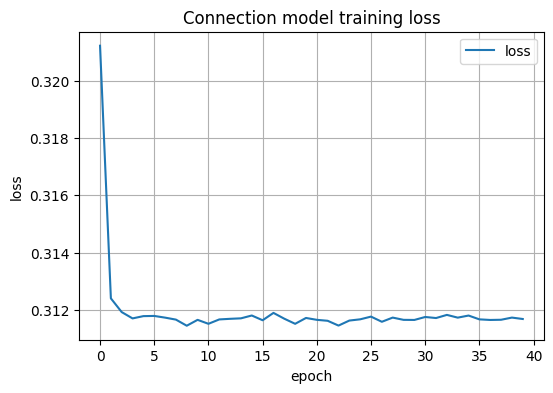

In [8]:
# ============================================================
# 7. 연결 모델 (ConnectionModel) 학습
# ============================================================

conn_model = ConnectionModel(n_users, n_items, EMB_DIM, N_LAYERS).to(device)
opt_conn = torch.optim.Adam(conn_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history_conn = {"loss": []}

for epoch in range(1, EPOCHS + 1):
    conn_model.train()
    perm = torch.randperm(len(train_u), device=device)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, len(train_u), BATCH_SIZE):
        idx = perm[start:start+BATCH_SIZE]
        if idx.numel() == 0:
            continue

        u_batch = train_u[idx]
        i_batch = train_i[idx]
        w_batch = train_w[idx]

        # 현재 파라미터로 임베딩 계산
        u_emb, i_emb = conn_model(edge_index, edge_weight_conn)

        # positive score
        pos_score = (u_emb[u_batch] * i_emb[i_batch]).sum(dim=-1)

        # negative 샘플
        neg_items = sample_negative_items(len(u_batch), NUM_NEG, n_items, device)
        neg_score = (u_emb[u_batch].unsqueeze(1) * i_emb[neg_items]).sum(dim=-1)

        diff = pos_score.view(-1, 1) - neg_score
        loss_per_pos = -torch.log(torch.sigmoid(diff) + 1e-8).mean(dim=1)
        loss = (loss_per_pos * w_batch).mean()

        opt_conn.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(conn_model.parameters(), max_norm=1.0)
        opt_conn.step()

        epoch_loss += loss.item()
        n_batches += 1

    history_conn["loss"].append(epoch_loss / max(1, n_batches))

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Conn] Epoch {epoch}/{EPOCHS} - loss {history_conn['loss'][-1]:.4f}")

plot_history(history_conn, "Connection model training loss")


[Qual] Epoch 1/40 - loss 1.4944, val RMSE 1.1391
[Qual] Epoch 5/40 - loss 0.7343, val RMSE 1.8708
[Qual] Epoch 10/40 - loss 0.6734, val RMSE 1.8749
[Qual] Epoch 15/40 - loss 0.6603, val RMSE 1.8615
[Qual] Epoch 20/40 - loss 0.6557, val RMSE 1.9368
[Qual] Epoch 25/40 - loss 0.6514, val RMSE 1.8998
[Qual] Epoch 30/40 - loss 0.6468, val RMSE 1.8601
[Qual] Epoch 35/40 - loss 0.6479, val RMSE 1.9470
[Qual] Epoch 40/40 - loss 0.6454, val RMSE 1.8989


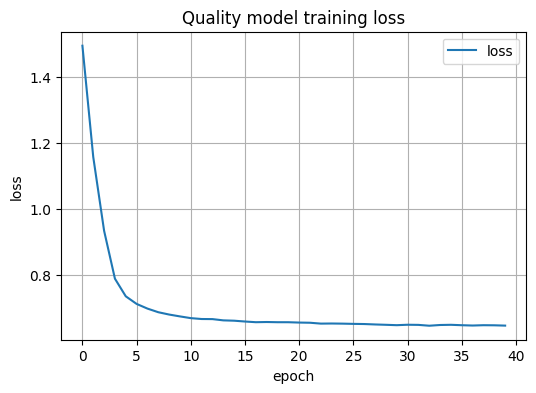

In [9]:
# ============================================================
# 8. 품질 모델 (QualityModel) 학습
# ============================================================

quality_model = QualityModel(n_users, n_items, EMB_DIM, N_LAYERS).to(device)
opt_qual = torch.optim.Adam(quality_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history_qual = {"loss": [], "rmse": []}

val_u_tensor = torch.LongTensor(val_df["user_idx"].values).to(device)
val_i_tensor = torch.LongTensor(val_df["item_idx"].values).to(device)
val_r_tensor = torch.FloatTensor(val_df["rating"].values).to(device) if len(val_df) > 0 else None

for epoch in range(1, EPOCHS + 1):
    quality_model.train()
    perm = torch.randperm(len(train_u), device=device)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, len(train_u), BATCH_SIZE):
        idx = perm[start:start+BATCH_SIZE]
        if idx.numel() == 0:
            continue

        u_batch = train_u[idx]
        i_batch = train_i[idx]
        r_batch = train_r[idx]

        u_emb, i_emb = quality_model(edge_index, edge_weight_quality)

        pos_score = (u_emb[u_batch] * i_emb[i_batch]).sum(dim=-1)
        neg_items = sample_negative_items(len(u_batch), NUM_NEG, n_items, device)
        neg_score = (u_emb[u_batch].unsqueeze(1) * i_emb[neg_items]).sum(dim=-1)

        # BPR part
        diff = pos_score.view(-1, 1) - neg_score
        loss_bpr = -torch.log(torch.sigmoid(diff) + 1e-8).mean()

        # MSE part
        pred_rating = quality_model.predict_rating(u_batch, i_batch, edge_index, edge_weight_quality)
        loss_mse = nn.functional.mse_loss(pred_rating, r_batch)

        loss = loss_bpr + LAMBDA_MSE * loss_mse

        opt_qual.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(quality_model.parameters(), max_norm=1.0)
        opt_qual.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / max(1, n_batches)
    history_qual["loss"].append(avg_loss)

    # validation RMSE 모니터링
    if epoch % 5 == 0 or epoch == 1:
        quality_model.eval()
        with torch.no_grad():
            if val_r_tensor is not None and len(val_df) > 0:
                val_pred = quality_model.predict_rating(
                    val_u_tensor, val_i_tensor, edge_index, edge_weight_quality
                )
                rmse = torch.sqrt(nn.functional.mse_loss(val_pred, val_r_tensor)).item()
            else:
                rmse = float("nan")
        history_qual["rmse"].append(rmse)
        print(f"[Qual] Epoch {epoch}/{EPOCHS} - loss {avg_loss:.4f}, val RMSE {rmse:.4f}")

plot_history(history_qual, "Quality model training loss")


In [10]:
# ============================================================
# 9. 앙상블: alpha & threshold 튜닝, Test metric 계산
# ============================================================

conn_model.eval()
quality_model.eval()

# 1) train 데이터에서 점수 분포 뽑아서 정규화 범위 추정
BATCH = 4096
cca_scores_train = []
ccb_ratings_train = []

with torch.no_grad():
    u_conn_all, i_conn_all = conn_model(edge_index, edge_weight_conn)
    u_qual_all, i_qual_all = quality_model(edge_index, edge_weight_quality)

    for start in range(0, len(train_df), BATCH):
        end = min(start + BATCH, len(train_df))
        u_idx = torch.LongTensor(train_df["user_idx"].values[start:end]).to(device)
        i_idx = torch.LongTensor(train_df["item_idx"].values[start:end]).to(device)

        s_conn = (u_conn_all[u_idx] * i_conn_all[i_idx]).sum(dim=-1).cpu().numpy()
        s_qual = quality_model.predict_rating(u_idx, i_idx, edge_index, edge_weight_quality).cpu().numpy()

        cca_scores_train.append(s_conn)
        ccb_ratings_train.append(s_qual)

cca_scores_train = np.concatenate(cca_scores_train)
ccb_ratings_train = np.concatenate(ccb_ratings_train)

# 연결 점수는 1~99 percentile로 자르고, rating은 [0.5, 5.0] 고정
CCA_MIN, CCA_MAX = np.percentile(cca_scores_train, 1), np.percentile(cca_scores_train, 99)
CCB_MIN, CCB_MAX = 0.5, 5.0

print(f"CCA score range (1~99p): [{CCA_MIN:.4f}, {CCA_MAX:.4f}]")

def normalize(x, vmin, vmax):
    return np.clip((x - vmin) / (vmax - vmin + 1e-8), 0.0, 1.0)

# 2) validation set에서 positive / negative 샘플 만들기
#    (val의 실제 good pair + random negative pair)
val_pos_u = val_df["user_idx"].values
val_pos_i = val_df["item_idx"].values

val_neg_u = []
val_neg_i = []
known_edges = set(zip(df["user_idx"], df["item_idx"]))

for _ in range(len(val_df)):
    while True:
        u = np.random.randint(0, n_users)
        i = np.random.randint(0, n_items)
        if (u, i) not in known_edges:
            val_neg_u.append(u)
            val_neg_i.append(i)
            break

with torch.no_grad():
    vp_u = torch.LongTensor(val_pos_u).to(device)
    vp_i = torch.LongTensor(val_pos_i).to(device)
    vn_u = torch.LongTensor(val_neg_u).to(device)
    vn_i = torch.LongTensor(val_neg_i).to(device)

    u_conn_all, i_conn_all = conn_model(edge_index, edge_weight_conn)

    cca_pos = (u_conn_all[vp_u] * i_conn_all[vp_i]).sum(dim=-1).cpu().numpy()
    cca_neg = (u_conn_all[vn_u] * i_conn_all[vn_i]).sum(dim=-1).cpu().numpy()

    ccb_pos = quality_model.predict_rating(vp_u, vp_i, edge_index, edge_weight_quality).cpu().numpy()
    ccb_neg = quality_model.predict_rating(vn_u, vn_i, edge_index, edge_weight_quality).cpu().numpy()

cca_pos_n = normalize(cca_pos, CCA_MIN, CCA_MAX)
cca_neg_n = normalize(cca_neg, CCA_MIN, CCA_MAX)
ccb_pos_n = normalize(ccb_pos, CCB_MIN, CCB_MAX)
ccb_neg_n = normalize(ccb_neg, CCB_MIN, CCB_MAX)

# 3) alpha grid-search (beta = 1 - alpha)
alphas = [0.3, 0.4, 0.5, 0.6, 0.7]
best_alpha = 0.5
best_auc = 0.0

for alpha in alphas:
    beta = 1.0 - alpha
    pos_score = alpha * cca_pos_n + beta * ccb_pos_n
    neg_score = alpha * cca_neg_n + beta * ccb_neg_n

    labels = np.concatenate([np.ones_like(pos_score), np.zeros_like(neg_score)])
    scores = np.concatenate([pos_score, neg_score])

    auc_val = roc_auc_score(labels, scores)
    print(f"alpha={alpha:.1f}, val AUC={auc_val:.4f}")

    if auc_val > best_auc:
        best_auc = auc_val
        best_alpha = alpha

ALPHA = best_alpha
BETA  = 1.0 - best_alpha
print(f"\n선택된 alpha={ALPHA:.2f}, beta={BETA:.2f} (val AUC={best_auc:.4f})")

# 4) threshold 튜닝 (F1 최대 + O-ratio 제약 0.2~0.5)
pos_score = ALPHA * cca_pos_n + BETA * ccb_pos_n
neg_score = ALPHA * cca_neg_n + BETA * ccb_neg_n

labels = np.concatenate([np.ones_like(pos_score), np.zeros_like(neg_score)])
scores = np.concatenate([pos_score, neg_score])

best_f1 = 0.0
best_th = 0.5

for th in np.linspace(scores.min(), scores.max(), 100):
    preds = (scores >= th).astype(int)
    o_ratio = preds.mean()   # O 비율
    if 0.2 <= o_ratio <= 0.5:   # 너무 많이/적게 추천하지 않도록
        f1_val = f1_score(labels, preds)
        if f1_val > best_f1:
            best_f1 = f1_val
            best_th = th

THRESHOLD = best_th
print(f"선택된 threshold={THRESHOLD:.4f}, val F1={best_f1:.4f}")


CCA score range (1~99p): [-0.0004, 1.7783]
alpha=0.3, val AUC=0.7492
alpha=0.4, val AUC=0.7525
alpha=0.5, val AUC=0.7558
alpha=0.6, val AUC=0.7595
alpha=0.7, val AUC=0.7633

선택된 alpha=0.70, beta=0.30 (val AUC=0.7633)
선택된 threshold=0.1414, val F1=0.7068


In [11]:
# ============================================================
# 9-2. Test set 최종 metric 계산
# ============================================================

# test positive / negative 샘플
test_pos_u = test_df["user_idx"].values
test_pos_i = test_df["item_idx"].values

test_neg_u = []
test_neg_i = []

for _ in range(len(test_df)):
    while True:
        u = np.random.randint(0, n_users)
        i = np.random.randint(0, n_items)
        if (u, i) not in known_edges:
            test_neg_u.append(u)
            test_neg_i.append(i)
            break

with torch.no_grad():
    tp_u = torch.LongTensor(test_pos_u).to(device)
    tp_i = torch.LongTensor(test_pos_i).to(device)
    tn_u = torch.LongTensor(test_neg_u).to(device)
    tn_i = torch.LongTensor(test_neg_i).to(device)

    u_conn_all, i_conn_all = conn_model(edge_index, edge_weight_conn)

    cca_pos = (u_conn_all[tp_u] * i_conn_all[tp_i]).sum(dim=-1).cpu().numpy()
    cca_neg = (u_conn_all[tn_u] * i_conn_all[tn_i]).sum(dim=-1).cpu().numpy()

    ccb_pos = quality_model.predict_rating(tp_u, tp_i, edge_index, edge_weight_quality).cpu().numpy()
    ccb_neg = quality_model.predict_rating(tn_u, tn_i, edge_index, edge_weight_quality).cpu().numpy()

cca_pos_n = normalize(cca_pos, CCA_MIN, CCA_MAX)
cca_neg_n = normalize(cca_neg, CCA_MIN, CCA_MAX)
ccb_pos_n = normalize(ccb_pos, CCB_MIN, CCB_MAX)
ccb_neg_n = normalize(ccb_neg, CCB_MIN, CCB_MAX)

test_pos_score = ALPHA * cca_pos_n + BETA * ccb_pos_n
test_neg_score = ALPHA * cca_neg_n + BETA * ccb_neg_n

y_true = np.concatenate([np.ones_like(test_pos_score), np.zeros_like(test_neg_score)])
y_score = np.concatenate([test_pos_score, test_neg_score])
y_pred  = (y_score >= THRESHOLD).astype(int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
o_ratio = y_pred.mean()

print("\n====== FINAL TEST METRICS ======")
print(f"AUC-ROC   : {roc_auc:.4f}")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"O-ratio   : {o_ratio:.4f}")
print("================================")



====== FINAL TEST METRICS ======
AUC-ROC   : 0.8597
Accuracy  : 0.7681
Precision : 0.7395
Recall    : 0.8279
F1-score  : 0.7812
O-ratio   : 0.5598


In [17]:
# ============================================================
# 10. 임의의 파일에서 O/X 추천 출력
# ============================================================

def predict_for_file(test_csv_path: str):
    """
    test_csv_path: 'user,item' 형식의 csv.
    결과 DataFrame(user, item, recommend)와 포맷 출력까지 수행.
    """
    test_in = pd.read_csv(test_csv_path)

    # rating 칼럼이 따라와도 무시
    test_in = test_in[["user", "item"]]

    results = []

    # 미리 전체 임베딩/파라미터 확보
    with torch.no_grad():
        u_conn_all, i_conn_all = conn_model(edge_index, edge_weight_conn)
        u_qual_all, i_qual_all = quality_model(edge_index, edge_weight_quality)

    # user 단위로 그룹
    for user_id, group in test_in.groupby("user"):
        if user_id not in user2idx:
            # 완전 cold user → 전부 X
            for _, row in group.iterrows():
                results.append({"user": row["user"], "item": row["item"], "recommend": "X"})
            continue

        u_idx = user2idx[user_id]
        cnt_train = user_interaction_count.get(u_idx, 0)
        K_user = user_k.get(u_idx, 2)

        items_valid = []
        rows_valid = []

        for _, row in group.iterrows():
            item_id = row["item"]
            if item_id not in item2idx:
                # 모르는 item → X
                results.append({"user": row["user"], "item": row["item"], "recommend": "X"})
                continue

            i_idx = item2idx[item_id]

            # train에서 이미 산 아이템은 추천 대상에서 제거
            if i_idx in user_train_items[u_idx]:
                results.append({"user": row["user"], "item": row["item"], "recommend": "X"})
                continue

            items_valid.append(i_idx)
            rows_valid.append(row)

        if len(items_valid) == 0:
            continue

        u_tensor = torch.LongTensor([u_idx] * len(items_valid)).to(device)
        i_tensor = torch.LongTensor(items_valid).to(device)

        with torch.no_grad():
            # 연결 점수
            s_conn = (u_conn_all[u_tensor] * i_conn_all[i_tensor]).sum(dim=-1).cpu().numpy()
            # 품질 점수
            s_qual = quality_model.predict_rating(
                u_tensor, i_tensor, edge_index, edge_weight_quality
            ).cpu().numpy()

        s_conn_n = normalize(s_conn, CCA_MIN, CCA_MAX)
        s_qual_n = normalize(s_qual, CCB_MIN, CCB_MAX)
        final_scores = ALPHA * s_conn_n + BETA * s_qual_n

        # threshold 기준으로 1차 선택
        idx_all = np.arange(len(final_scores))
        above = idx_all[final_scores >= THRESHOLD]

        selected = None

        if len(above) == 0:
            # 아무 것도 넘어오지 않으면 상위 K_user 선택
            top_idx = np.argsort(final_scores)[-min(K_user, len(final_scores)):]
            selected = set(top_idx)
        else:
            # 너무 많으면 상위 K_user만
            if len(above) > K_user:
                scores_above = final_scores[above]
                top_local = np.argsort(scores_above)[-K_user:]
                selected = set(above[top_local])
            else:
                # threshold 통과 개수가 K_user 이하이면 그대로 사용,
                # 하지만 "10개 이하인 유저는 2개 추천" 제약이 있으므로
                # cnt_train <= 10 이고 통과 개수가 2개보다 적으면 top-2로 강제
                if cnt_train <= 10 and len(above) < 2 and len(final_scores) >= 2:
                    top_idx = np.argsort(final_scores)[-2:]
                    selected = set(top_idx)
                else:
                    selected = set(above)

        # 실제 행에 O/X 부여
        for idx, row in enumerate(rows_valid):
            rec = "O" if idx in selected else "X"
            results.append({"user": row["user"], "item": row["item"], "recommend": rec})

    preds_df = pd.DataFrame(results)
    return preds_df


def print_formatted_results(preds_df: pd.DataFrame):
    total = len(preds_df)
    rec_cnt = (preds_df["recommend"] == "O").sum()
    not_cnt = total - rec_cnt

    print("====================")
    print(f"{'user':<20}{'item':<20}{'recommend':<10}")
    for _, row in preds_df.iterrows():
       print(f"{str(row['user']):<20}{str(row['item']):<20}{row['recommend']:<10}")
    print("====================")
    print(f"Total recommends = {rec_cnt}/{total}")
    print(f"Total not recommends = {not_cnt}/{total}")


# 사용 예시 (교수님이 주는 test 파일 이름으로 수정)
TEST_FILE = "/content/test.csv"
preds = predict_for_file(TEST_FILE)
print_formatted_results(preds)


user                item                recommend 
A100UZGZNZ9ZYN      B002AYIJNY          O         
A107TOIRSQ1JWX      B0077DRNYE          X         
A11H0WJS80I6PO      B002C0Z4OS          O         
A12V99A19RKUAL      B006SXN8VQ          O         
A13DOLMII1JPXC      B0029NQNWU          O         
A13LAE0YTXA11B      B0002DGRZC          O         
A13MS1JQG2ADOJ      B0002DGRZC          O         
A1421EDED1JI4I      B006SXN8VQ          O         
A159UJ2KI3A32E      B00028LU40          X         
A15B9GRD3DF13X      B000CQBZQK          O         
A16QUDK9MXGT58      B0002DGRZC          O         
A17CEBYTEJMAB3      B003AOIN7A          X         
A17NHG3B5LMUIY      B0025VQJK2          X         
A186Y1BDGRGAOQ      B0002DGRZC          O         
A1AG7JAJUY175Y      B000KGW27S          X         
A1B4TXE58QSYVH      B005GTXSVS          X         
A1BFRTDMLD15UR      B0029NQNWU          X         
A1CH9ILS0DCSVR      B000CQBZQK          O         
A1CH9ILS0DCSVR      B000CQBZQK 